In [22]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf
from python_files import TLM_tests as TT
from python_files import ETLM_code as ETLMC
from python_files import LETLM_code as LETLMC
from python_files import IETLM_code_generic as IETLMC
torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_96 = 8 # The Lorenz 96 forcing term
dt = 0.01 # This gives a time step of six hours
timesteps =  30   #14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_96)


  0%|          | 0/300 [00:00<?, ?it/s]/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_99773/1506095011.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
100%|██████████| 300/300 [00:08<00:00, 34.37it/s]


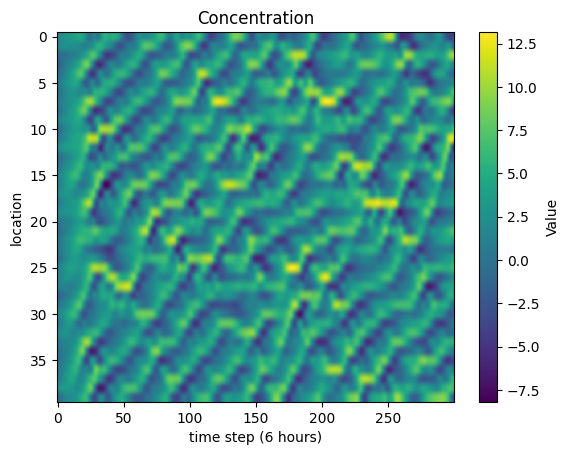

In [24]:
# In this cell we want to run the Lorenz 96 model 
# We also want to save the outputs to a folder so we can verify the spin up

#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 #0.05 #This gives a time step of six hours
timesteps =  300 #14400  #14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)

# We now set our initial state vector
x = torch.randn(N,1)


trajectory = []
times = []
dust_mass = []

t = 0.0
x_values = np.arange(1, N+1)  
for i in tqdm(range(timesteps)):
    # print(i)
    plt.title(f' Lorenz 96 after time step = {i:.2f}')
    plt.plot(x_values, x)
    plt.legend()
    # plt.savefig(f'/Users/imilesfine/PhD Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    plt.savefig(f'/Users/imilesfine/PhD_Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    # /Users/imilesfine/PhD Work2026/Lorenz_basic
    plt.clf()



    trajectory.append(x.clone())  # store current state
    times.append(t)
    
    x = bf.CN_L96(x, model_parameters)
    t += dt


trajectory = torch.stack(trajectory).squeeze()  # shape becomes (300, 40)
times = torch.tensor(times)
C_sol = trajectory[:, :N].T   # shape: (time, space)
u_sol = trajectory[:, N:].T




plt.imshow(C_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Concentration")
plt.show()


In [25]:
# We will start by defining our error function
def norm_error(x_g,x_pert, model, M, model_parameters):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = x_out_pert - x_out_unpert - torch.matmul(M, x_pert)
    return diff


def normalisor(x_g, x_pert, model_parameters, M, model):
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    norm = x_out_pert - x_out_unpert
    return norm

def alt_TLM_test(x_g, x_pert, model_parameters, M, model):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = sum(abs(x_out_pert - x_out_unpert - torch.matmul(M, x_pert)))
    average = sum(abs(x_pert))
    return (diff/average)/N
    

# We will now define a very quick generic TLM test that will be used for the multistep TLM test 
def generic_TLM_test(diff, norm):
    error = math.sqrt(torch.matmul(diff.T, diff)/torch.matmul(norm.T, norm))
    return error

In [26]:
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results = []
trials = 50
spin_up_time = 1000
for i in perturbations:
    sd = 10**(-i) #(-1*perturbations[i])
    # print(sd)
    ensemble_size = 150
    model = bf.CN_L96
    # model = test_model

    # We first need to spin up the model
    x_0 = torch.randn(N,1)
    x = IETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
    x_g = x
    ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)

    # plt.imshow(ETLM,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("ETLM")
    # plt.show()
    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, ETLM, model_parameters)
        norm = normalisor(x_g, x_pert, model_parameters, ETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, ETLM, model)
    results.append(error/trials)


    

    

100%|██████████| 150/150 [00:01<00:00, 117.34it/s]


In [27]:
# We will now do the same for the Jacobian generated by the pytorch function 
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results_pytorch = []
trials = 50
spin_up_time = 1000
for i in perturbations:
    sd = 10**(-1* i)
    model = bf.CN_L96

    # We first need to spin up the model
    # x_0 = torch.randn(N)
    # x = ETLMC. spin_up(x, model_parameters, model)
    # x_g = x
    # ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)
    
    x_0 = torch.randn(N,1)
    x = ETLMC.spin_up(x, model_parameters, model, spin_up_time)
    x_g = x

    y = x_g.clone().detach().requires_grad_(True)

    J = torch.autograd.functional.jacobian(lambda y: model(y, model_parameters),y).squeeze()

    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, J, model_parameters)
        norm = normalisor(x_g, x_pert,  model_parameters, J, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, J, model)
    results_pytorch.append(error/trials)

In [28]:
# We will now run the LETLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations

perturbations = [0,1,2,3,4,5,6,7,8,9,10]
# perturbations = [7]

results_local = []
trials = 50
spin_up_time = 1000
x_0 = torch.randn(N,1)
x = LETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
x_g = x.clone()
for i in tqdm(perturbations):
    sd = 10**(-i) #(-1*perturbations[i])
    # print('sd:',sd)
    ensemble_size = 16
    model = bf.CN_L96

    # model = test_model

    # We first need to spin up the model
    
    LETLM = LETLMC.LETLM_generator(ensemble_size, sd, x, model_parameters, model)

    # plt.imshow(LETLM,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("LETLM")
    # plt.show()
    # print(LETLM[i,:])
    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, LETLM, model_parameters)
        norm = normalisor(x_g, x_pert, model_parameters, LETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, LETLM, model)
        # print(error)
        # print(error.shape)
    results_local.append(error/trials)
    

    

100%|██████████| 11/11 [00:15<00:00,  1.44s/it]


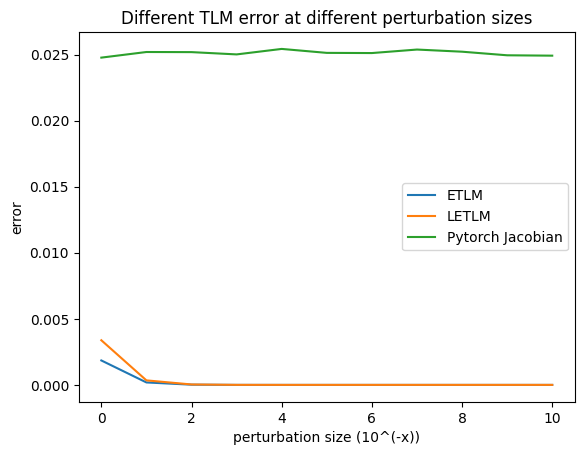

In [29]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )



plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()

plt.show()

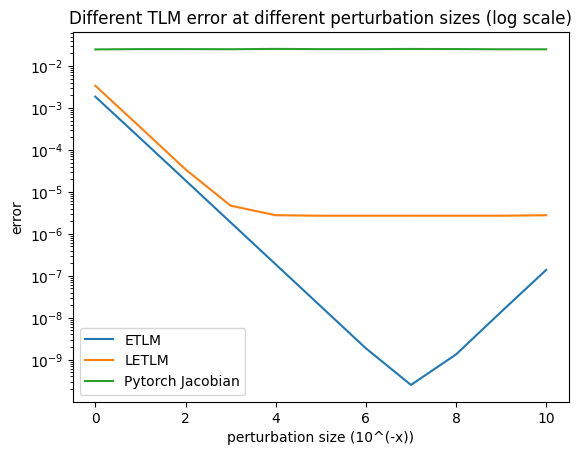

In [30]:
plt.yscale('log')
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )
plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()

100%|██████████| 40/40 [00:00<00:00, 9210.15it/s]

0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

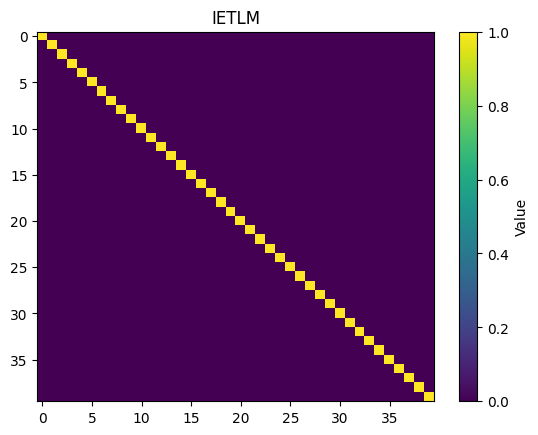

100%|██████████| 40/40 [00:00<00:00, 8583.89it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

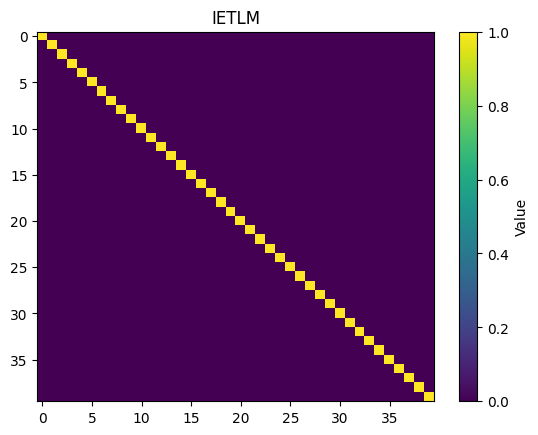

100%|██████████| 40/40 [00:00<00:00, 8685.66it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

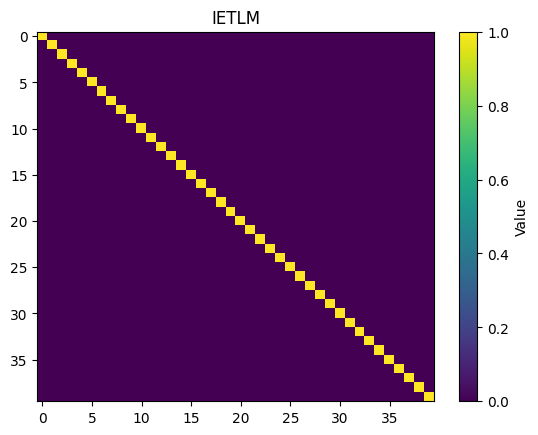

100%|██████████| 40/40 [00:00<00:00, 9101.23it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

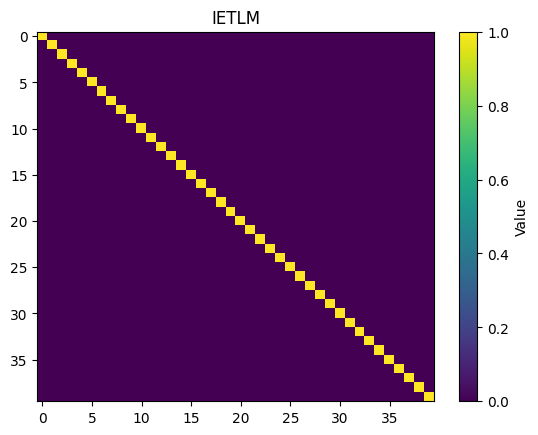

100%|██████████| 40/40 [00:00<00:00, 8814.80it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

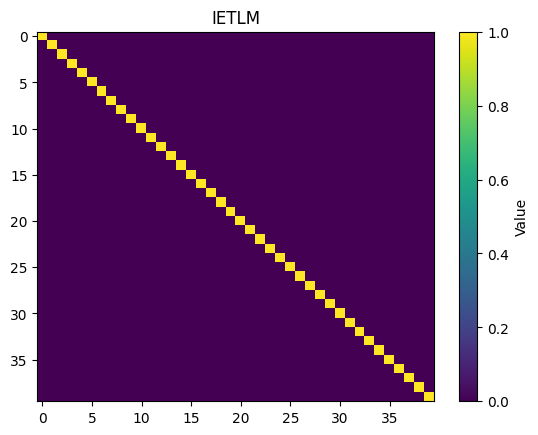

100%|██████████| 40/40 [00:00<00:00, 9231.44it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

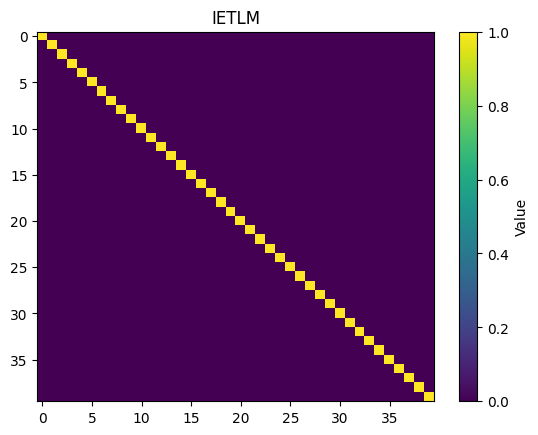

100%|██████████| 40/40 [00:00<00:00, 8978.98it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

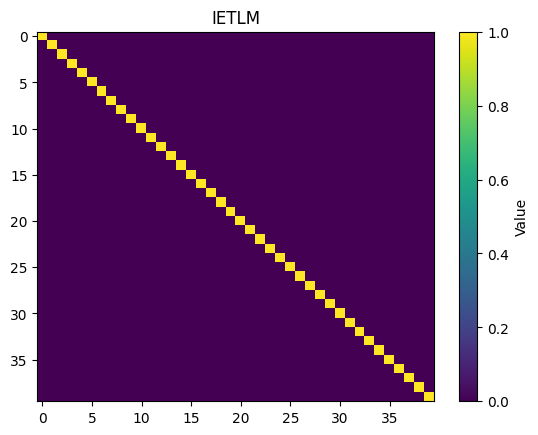

100%|██████████| 40/40 [00:00<00:00, 9285.08it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

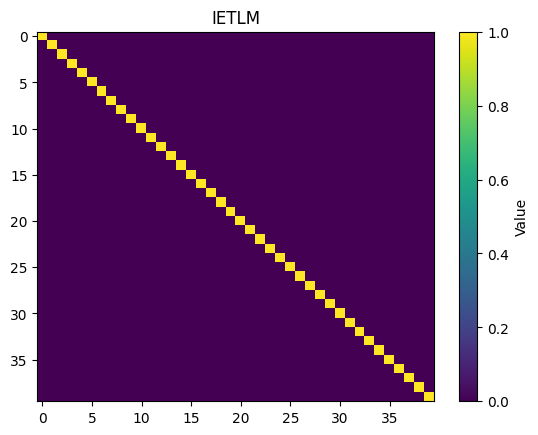

100%|██████████| 40/40 [00:00<00:00, 8938.31it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

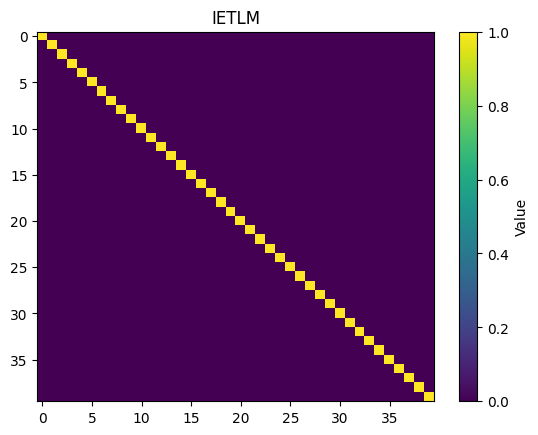

100%|██████████| 40/40 [00:00<00:00, 9136.42it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

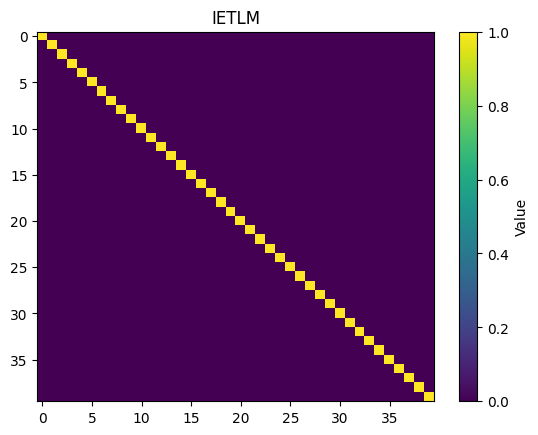

100%|██████████| 40/40 [00:00<00:00, 9128.47it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

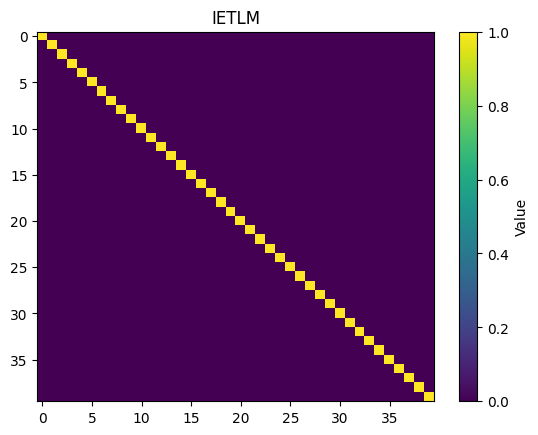

In [ ]:
# We will now run the IETLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations

perturbations = [0,1,2,3,4,5,6,7,8,9,10]
# perturbations = [7]

results_IETLM = []
trials = 50
spin_up_time = 1000
stencil_members_current = [-2,-1,0,1,2,3]
stencil_members_future = [-2,-1,0,1,2,3]
stencil_members_large = [stencil_members_future, stencil_members_current]

x_0 = torch.randn(N,1)
x = IETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
x_g = x.clone()
for i in perturbations:
    sd = 10**(-i) #(-1*perturbations[i])
    # print('sd:',sd)
    ensemble_size = 40
    model = bf.rk4_L96

    # model = test_model

    # We first need to spin up the model
    
    N_tilde, L_tilde = IETLMC.IETLM_generator(ensemble_size, sd, x, model_parameters, model, stencil_members_large)
    IETLM = torch.inverse(N_tilde) @ L_tilde

    plt.imshow(IETLM,aspect='auto', cmap='viridis')
    plt.colorbar(label='Value')
    plt.title("IETLM")
    plt.show()
    # print(LETLM[i,:])
    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, IETLM, model_parameters)
        norm = normalisor(x_g, x_pert, model_parameters, IETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, IETLM, model)
        # print(error)
        # print(error.shape)
    results_IETLM.append(error/trials)
    

    

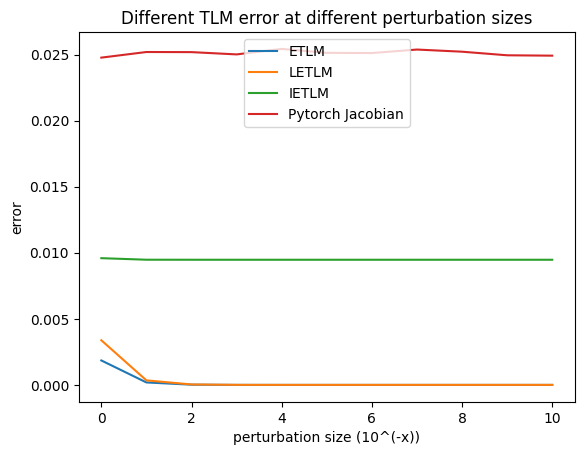

In [32]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_IETLM,label = 'IETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )



plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()

plt.show()

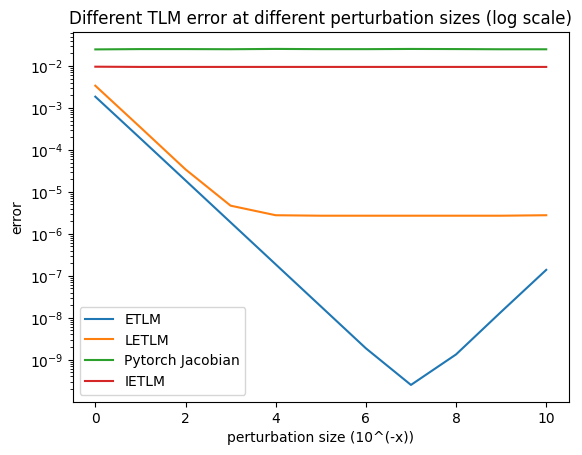

In [33]:
plt.yscale('log')
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )
plt.plot(perturbations, results_IETLM,label = 'IETLM' )
plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()

In [34]:
# I will now attempt to recreate the plots for Bishop and Eizenberg
# We start by generating a random normal noise vector
model = bf.CN_L96
spin_up_time = 1000
(N, dx, dt, alpha, beta, F_L96) = model_parameters
 # we now run the model to spin up the model
x_in = torch.rand((N,1))
results = x_in
for i in range(spin_up_time):
    x_out = model(x_in, model_parameters)
    results = torch.cat((results, x_out), dim = 1)
    x_in = x_out

In [35]:
dt = 0.1
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_96)
ensemble_size = 25
model = bf.CN_L96
spin_up_time = 1000
perturbation_size = 10**(-7)
x_values = np.arange(1, N+1)  




model_steps = 20
sd = 10**(-7)
test_pert = torch.randn((N,1))*sd
test_pert_ETLM = test_pert
test_pert_LETLM = test_pert
test_pert_IETLM = test_pert
test_pert_Jac = test_pert



for i in range(model_steps):
    # we first generate the LETLM, IETLM, ETLM and Jacobian for each time step 
    plt.title(f' Lorenz 96 after time step = {i:.2f}')
    plt.plot(x_values, test_pert_ETLM, label = 'ETLM')
    plt.plot(x_values, test_pert_LETLM, label = 'LETLM')
    plt.plot(x_values, test_pert_IETLM, label = 'IETLM')
    plt.plot(x_values, test_pert_Jac, label = 'Jacobian')
    plt.plot(x_values, test_pert, label = 'Model')
    plt.legend()
    # plt.savefig(f'/Users/imilesfine/PhD Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    plt.savefig(f'/Users/imilesfine/PhD_Work/2026/Lorenz_basic/TLM_comp_CN/plot_{i + 1}.png')
    # /Users/imilesfine/PhD Work2026/Lorenz_basic
    plt.clf()

    

    # We now generate the TLMs for the current state vector

    # We start with the LETLM
    ensemble_size = 16
    LETLM = LETLMC.LETLM_generator(ensemble_size, sd, x_out, model_parameters, model)

    # We now the the IETLM
    ensemble_size = 30
    N_tilde, L_tilde = IETLMC.IETLM_generator(ensemble_size, sd, x_out, model_parameters, model, stencil_members_large)
    IETLM = torch.inverse(N_tilde) @ L_tilde

    # We now do the ETLM
    ensemble_size = 90
    ETLM, Chi, X  = ETLMC.ETLM_generator(ensemble_size, sd, x_out, model_parameters, model)

    # We finally do the Pytorch autograd function
    y = x_out.squeeze().clone().detach().requires_grad_(True)
    Jac = torch.autograd.functional.jacobian(lambda y: model(y, model_parameters), y).squeeze()   
    # print(Jac.shape)

    # We now use this to calculate the values of the next perturbation
    test_pert_ETLM = ETLM @ test_pert_ETLM
    test_pert_LETLM = LETLM @ test_pert_LETLM
    test_pert_IETLM = IETLM @ test_pert_IETLM
    test_pert_Jac =  Jac @ test_pert_Jac

    test_pert = model(x_out + test_pert, model_parameters) - model(x_out, model_parameters)


    # We then run the model again to get to the next time step
    x_in = x_out
    x_out = model(x_in, model_parameters)






    


100%|██████████| 30/30 [00:00<00:00, 87.23it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

100%|██████████| 30/30 [00:00<00:00, 91.43it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

100%|██████████| 30/30 [00:00<00:00, 90.14it/s]


...

0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

100%|██████████| 30/30 [00:00<00:00, 91.38it/s]


0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
0
[-2, -1, 0, 1, 2, 3]
-2
-1
0
1
2
3
6
torch.Size([6, 1])
6
torch.Size([6, 1])
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
1
[-2, -1, 0, 1, 2, 3]
-1
0
1
2
3
4
6
torch.Size([6, 1])
6
torch.Size([6, 1])
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
2
[-2, -1, 0, 1, 2, 3]
0
1
2
3
4
5
6
torch.Size([6, 1])
6
torch.Size([6, 1])
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
3
[-2, -1, 0, 1, 2, 3]
1
2
3
4
5
6
6
torch.Size([6, 1])
6
torch.Size([6, 1])
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
4
[-2, -1, 0, 1, 2, 3]
2
3
4
5
6
7
6
torch.Size([6, 1])
6
torch.Size([6, 1])
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
5
[-2, -1, 0, 1, 2, 3]
3
4
5
6
7
8
6
torch.Size([6, 1])
6
torch.Size([6, 1])
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
[-2, -1, 0, 1, 2, 3]
4
5
6
7
8
9
6
torch.Size([6, 1])
6
torch.Size([6, 1])
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
7
[-2, -1, 0, 1, 2, 3]
5
6
7
8
9
10
6
torch.Size([6, 1])
6
torch.Size([6, 1])
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
8
[-2, -1, 0, 1, 2, 3]
6
7
8
9
10
11
6
torch.Size([6, 1])
6

100%|██████████| 90/90 [00:01<00:00, 88.27it/s]


<Figure size 640x480 with 0 Axes>

In [36]:
# I am now going to test an individual line to see how to fix this

100%|██████████| 90/90 [00:00<00:00, 91.50it/s]

torch.Size([40])


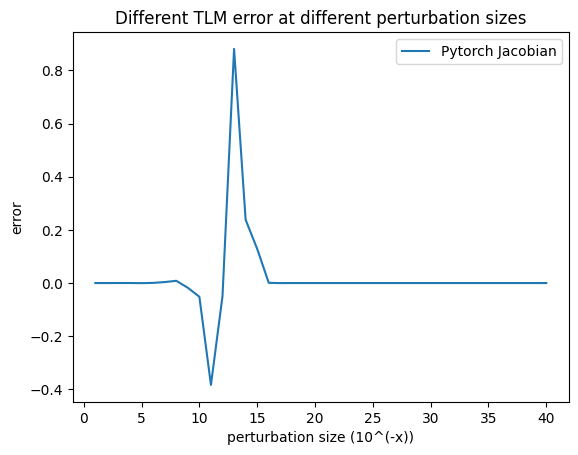

In [37]:
# I will now attempt to recreate a single line of the ETLM using the LETLM 
# We will use a perturbation size of 10**(-7) 
sd = 10**(-7)
x_values = np.arange(1, N+1)  
grid_index = 12


#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  30   #14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_96)
model = bf.CN_L96

# We now need to spin up the model 

spin_up_time = 1000
x_0 = torch.randn(N,1)
x = LETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
x_g = x.clone()

# We will now generate the ETLM
ensemble_size = 90
ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)
# we will now grab out the 21st row and try to recreate it using the LETLM 

goal = ETLM[grid_index,:]
print(goal.shape)

plt.plot(x_values, goal,label = 'Pytorch Jacobian' )
plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()


  0%|          | 0/16 [00:00<?, ?it/s]/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_99773/3006572819.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
100%|██████████| 16/16 [00:00<00:00, 86.76it/s]


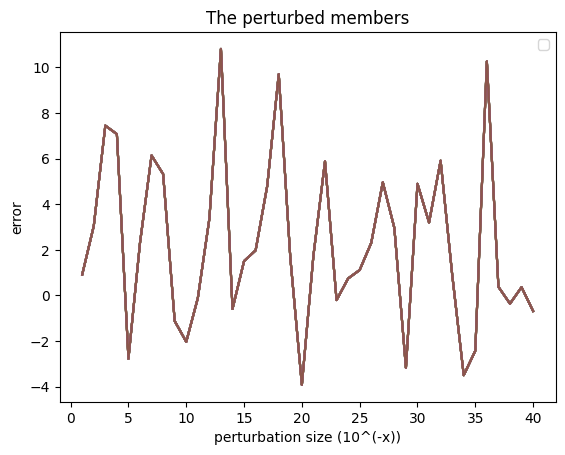

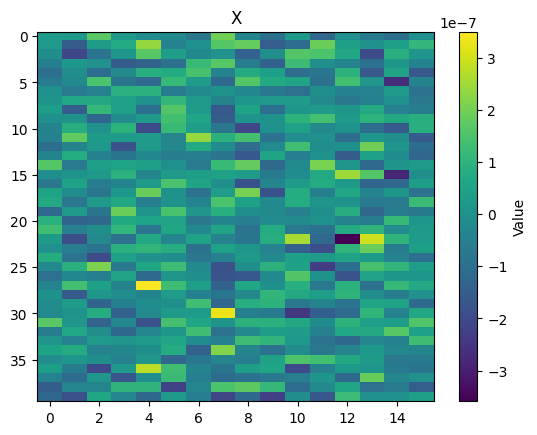

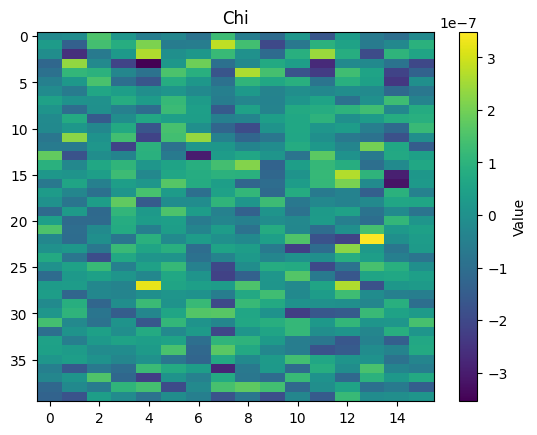

/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_99773/3006572819.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


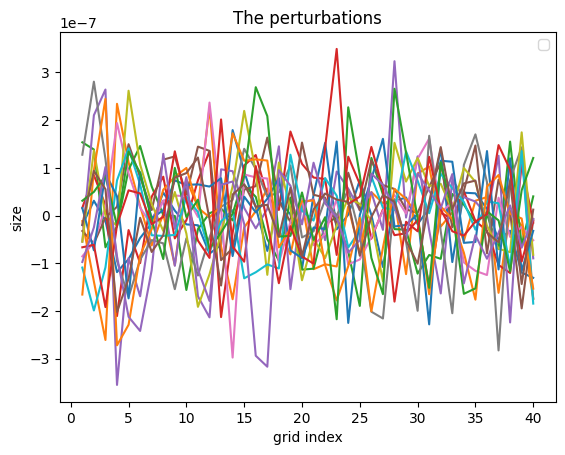

In [38]:
# We will now create the LETLM of the 21st row 
# The first step is to generate the ensembles of perturbations
ensemble_size = 16
X = torch.zeros(N, ensemble_size)
Chi = torch.zeros(N, ensemble_size)
x_out = x_g

for i in tqdm(range(ensemble_size)):
    x_pert = torch.randn(N,1)*sd
    # print(x_pert)
    x_in_pert = x_out + x_pert
    x_out_pert = model(x_in_pert,model_parameters)
    x_out_unpert = model(x_out, model_parameters)
    Chi_i = x_out_pert - x_out_unpert
    # print("x_out_pert shape:", x_out_pert.shape)
    # print("x_out_unpert shape:", x_out_unpert.shape)
    # print("Chi_i shape:", Chi_i.shape)
    X[:,i] = x_pert.squeeze()
    Chi[:,i] = Chi_i.squeeze()

    plt.plot(x_values, x_out_pert)
    plt.xlabel('perturbation size (10^(-x))')
    plt.ylabel('error')
    plt.title('The perturbed members')
    plt.legend()

plt.show()
plt.clf()


plt.imshow(X,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("X")
plt.show()

plt.imshow(Chi,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("Chi")
plt.show()

for i in range(ensemble_size):
    perts = Chi[:,i]
    plt.plot(x_values, perts)
    plt.xlabel('grid index')
    plt.ylabel('size')
    plt.title('The perturbations')
    plt.legend()



In [39]:
stencil_members_current = [-3,-2,-1,0,1,2,3,4]
stencil_members_future = stencil_members_current # [-2,-1,0,1,2,3]
stencil_members_large = [stencil_members_future,stencil_members_current]

In [40]:
# Now that we have our ensembles we can select the required members to calculate the 21st row
# We set the grid index to 20
sd = 10**(-7)

N_tilde, L_tilde = IETLMC.IETLM_generator(ensemble_size, sd, x, model_parameters, model, stencil_members_large)
IETLM = torch.inverse(N_tilde) @ L_tilde
 
M = IETLM[grid_index,:]

100%|██████████| 16/16 [00:00<00:00, 85.39it/s]


0
[-3, -2, -1, 0, 1, 2, 3, 4]
-3
-2
-1
0
1
2
3
4
0
[-3, -2, -1, 0, 1, 2, 3, 4]
-3
-2
-1
0
1
2
3
4
8
torch.Size([8, 1])
8
torch.Size([8, 1])
1
[-3, -2, -1, 0, 1, 2, 3, 4]
-2
-1
0
1
2
3
4
5
1
[-3, -2, -1, 0, 1, 2, 3, 4]
-2
-1
0
1
2
3
4
5
8
torch.Size([8, 1])
8
torch.Size([8, 1])
2
[-3, -2, -1, 0, 1, 2, 3, 4]
-1
0
1
2
3
4
5
6
2
[-3, -2, -1, 0, 1, 2, 3, 4]
-1
0
1
2
3
4
5
6
8
torch.Size([8, 1])
8
torch.Size([8, 1])
3
[-3, -2, -1, 0, 1, 2, 3, 4]
0
1
2
3
4
5
6
7
3
[-3, -2, -1, 0, 1, 2, 3, 4]
0
1
2
3
4
5
6
7
8
torch.Size([8, 1])
8
torch.Size([8, 1])
4
[-3, -2, -1, 0, 1, 2, 3, 4]
1
2
3
4
5
6
7
8
4
[-3, -2, -1, 0, 1, 2, 3, 4]
1
2
3
4
5
6
7
8
8
torch.Size([8, 1])
8
torch.Size([8, 1])
5
[-3, -2, -1, 0, 1, 2, 3, 4]
2
3
4
5
6
7
8
9
5
[-3, -2, -1, 0, 1, 2, 3, 4]
2
3
4
5
6
7
8
9
8
torch.Size([8, 1])
8
torch.Size([8, 1])
6
[-3, -2, -1, 0, 1, 2, 3, 4]
3
4
5
6
7
8
9
10
6
[-3, -2, -1, 0, 1, 2, 3, 4]
3
4
5
6
7
8
9
10
8
torch.Size([8, 1])
8
torch.Size([8, 1])
7
[-3, -2, -1, 0, 1, 2, 3, 4]
4
5
6
7
8
9
10
11


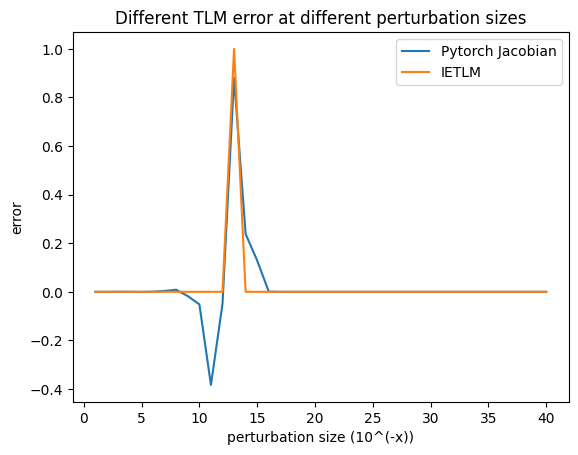

In [41]:
plt.plot(x_values, goal,label = 'Pytorch Jacobian' )
plt.plot(x_values, M,label = 'IETLM' )

plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()



In [42]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf
from python_files import TLM_tests as TT


torch.set_default_dtype(torch.float64)



def spin_up(x, model_parameters, model,spin_up_time):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in = x

    for i in range(spin_up_time):
        x_out = model(x_in, model_parameters)
        # print(x_out.shape)
        x_in = x_out
    return x_out

# We will now define a function that selects the 9 members of each row 
def member_past_selector(grid_index,X,N,ensemble_size):
    subset = torch.zeros(13,ensemble_size)
    for i in range(13):
        j = (grid_index +i - 8)%N
        # print(grid_index, j)
        subset[i,:] = X[j,:]
    return subset

def member_current_selector(grid_index,Xi,N,ensemble_size):
    subset = torch.zeros(1,ensemble_size)
    j = grid_index
    subset[0,:] = Xi[j,:]
    # print(subset.shape)
    return subset

def stencil_selector(grid_index, Ensemble, N, ensemble_size,stencil_members):

    i = grid_index
    print(i)
    print(stencil_members)

    subset = torch.zeros(len(stencil_members), ensemble_size)
    for ii in range(len(stencil_members)):
        j = grid_index + stencil_members[ii]
        print(j)
        subset[(ii%N),:] = Ensemble[(j%N),:]
        

    return subset


def put_in_place(n_i, N, N_tilde, grid_index, stencil_members):
    for i in range(len(stencil_members)):
        local = grid_index + stencil_members[i]
        N_tilde[grid_index, local%N] = n_i[i]
    return N_tilde

def little_IETLM(Xi_i, X_i, stencil_members_large):
    # Construct matrix
    # (1)
    Pi_half = torch.cat((Xi_i, -X_i), dim=0)
    Pi = Pi_half @ Pi_half.T
    # print(Pi_half.shape)

    # (2)
    # Compute smallest eigenpair
    eigenvals, eigenvecs = torch.linalg.eig(Pi)
    # print(eigenvals)

    # Smallest eigenvector (shape: [18])
    
    eigenvals, eigenvecs = torch.lobpcg(Pi, k=1,largest=False)


    # (3)
    # Split into two 9-vectors
    split = len(stencil_members_large[0])
    n_i = eigenvecs[:split]
    l_i = eigenvecs[split:]

    return n_i, l_i

def IETLM_generator(ensemble_size, sd, x_out, model_parameters, model, stencil_members_large):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    N_tilde = torch.zeros(N,N)
    L_tilde = torch.zeros(N,N)

    future_members = stencil_members_large[0]
    current_members = stencil_members_large[1]

    X = torch.zeros(N, ensemble_size)
    Chi = torch.zeros(N, ensemble_size)

    for i in tqdm(range(ensemble_size)):
        x_pert = torch.randn(N,1)*sd
        # print(x_pert)
        x_in_pert = x_out + x_pert
        x_out_pert = model(x_in_pert,model_parameters)
        x_out_unpert = model(x_out, model_parameters)
        Chi_i = x_out_pert - x_out_unpert
        # print("x_out_pert shape:", x_out_pert.shape)
        # print("x_out_unpert shape:", x_out_unpert.shape)
        # print("Chi_i shape:", Chi_i.shape)
        X[:,i] = x_pert.squeeze()
        Chi[:,i] = Chi_i.squeeze()

    for grid_index in range(N):


        X_i = member_past_selector(grid_index,X,N,ensemble_size)
        Chi_i = member_current_selector(grid_index,Chi,N,ensemble_size)

        n_i, l_i = little_IETLM(Chi_i, X_i, stencil_members_large)
        # print(n_i.shape)
        # print(l_i)

        # print(M_i.shape)
        # print(sum(abs(Chi_i - M_i @ X_i)))
        # print(sum(abs(Chi_i[:,0] - M_i @ X_i[:,0])))
        # x_pert_test = torch.randn(N,1)*sd
        # x_pert_test_t1 = model(x_pert_test,model_parameters)


        # print(sum(abs(Chi_i[:,0] - M_i @ X_i[:,0])))
        # print(sum(abs(x_pert_test_t1 - M_i @ x_pert_test)))

        # l_i = [1,2,3,4,5,6,7,8]


        N_tilde = put_in_place(n_i, N, N_tilde, grid_index, future_members)
        L_tilde = put_in_place(l_i, N, L_tilde, grid_index, current_members)


    
    return  N_tilde, L_tilde

